# In-situ sanity checks — DMI Disko Bay stations

**Goal:** decide which DMI stations have clean enough in-situ data to be used for validating
**snowfall rate** against climate-model and earth-observation (EO) data, for the two EO periods:

| Period | Range |
|---|---|
| **A** | 2023-04-08 → 2023-07-10 |
| **B** | all of 2025 |

**Data source:** the unified folder `DMI_API_DATA/` — one CSV per station covering
**2023-01-01 → 2025-12-31**, fetched from the keyless DMI Open Data API (metObs v2,
`opendataapi.dmi.dk`). If a station file is missing, section 2 re-fetches and rebuilds it.
The original DMI Report 25-08 files (1958–2024, in `DMI/`) are kept for reference but are **not**
read by this notebook; where they overlap, API and report values are identical.

**Stations evaluated** (the four active Disko Bay stations):

| Station | Name | Type | Lat | Lon | Elev (m) |
|---|---|---|---|---|---|
| 421900 | Qeqertarsuaq Heliport (04219) | MIT/SAVS airport | 69.2514 | −53.5147 | 2.7 |
| 422000 | Aasiaat (04220) | DMI/V98 automatic | 68.7081 | −52.8517 | 43 |
| 422100 | Mitt. Ilulissat (04221) | MIT/SAVS airport | 69.2403 | −51.0661 | 29 |
| 422400 | Mitt. Aasiaat (04224) | MIT/SAVS airport | 68.7219 | −52.7847 | 22.6 |

**Known context** (full profiling of the 1958–2024 report files in `data_analysis.md`):

- Only **422000 Aasiaat** measures precipitation (hourly `601`) and global radiation (`550`) —
  it is the only in-situ snowfall-rate reference. The airport (SAVS) stations measure neither.
- **421900** has a *known* sensor failure 2023-04-08 → 24 with air temperatures of +44…+92 °C —
  right inside period A; it serves as a built-in positive control for these checks.
- **422400** is silent 2021–2023 in the report files, but the API archive **does** hold its 2023
  data, so the unified source gives it a real period-A evaluation. Its record ends 2025-08-07.
- ⚠️ The API also serves **cloud cover at the SAVS airports** (421900/422100/422400) that DMI
  *excludes from its report products*: those ceilometers cannot report clear sky, so their cloud
  cover is overcast-biased. It passes the value checks here, but treat `801` from the airport
  stations as biased — prefer Aasiaat's (V98) cloud cover.
- No DMI station in Greenland reports snow depth (verified against the API registry); section 7
  documents that check. In-situ snow depth comes from other products (e.g. GEM ClimateBasis Disko).

**Outputs** (written to `results/`): `station_verdicts.csv` (PASS / PASS WITH WARNINGS / FAIL /
NO DATA per station × period, with reasons) and `clean_<station>_<period>.csv` (values that fail
critical checks masked to NaN, sentinels normalized) — downstream validation should consume the
cleaned files of stations that pass.

> Run this notebook from the project root.

## 1. Setup & configuration

All thresholds live in `THRESHOLDS` — tune them here, then re-run everything. Sunshine (`504`)
and 12-h precipitation (`603`) from the report files are not served by the API and are therefore
not part of the unified dataset.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import requests
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

BASE = Path.cwd().parent          # repo root (notebook runs from notebooks/)
API_DATA_DIR = BASE / 'data' / 'in-situ' / 'DMI_API_DATA'; API_DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = BASE / 'results'; RESULTS_DIR.mkdir(exist_ok=True)

STATIONS = {
    421900: {'name': 'Qeqertarsuaq Heliport', 'wmo': '04219', 'lat': 69.2514, 'lon': -53.5147, 'elev_m': 2.7,  'type': 'MIT/SAVS airport'},
    422000: {'name': 'Aasiaat',               'wmo': '04220', 'lat': 68.7081, 'lon': -52.8517, 'elev_m': 43,   'type': 'DMI/V98 automatic'},
    422100: {'name': 'Mitt. Ilulissat',       'wmo': '04221', 'lat': 69.2403, 'lon': -51.0661, 'elev_m': 29,   'type': 'MIT/SAVS airport'},
    422400: {'name': 'Mitt. Aasiaat',         'wmo': '04224', 'lat': 68.7219, 'lon': -52.7847, 'elev_m': 22.6, 'type': 'MIT/SAVS airport'},
    # stations outside Disko Bay with real 2025 hourly precip (API probe 2026-08-27)
    425000: {'name': 'Nuuk',                  'wmo': '04250', 'lat': 64.1833, 'lon': -51.7308, 'elev_m': 79.7, 'type': 'DMI synop'},
    433900: {'name': 'Ittoqqortoormiit',      'wmo': '04339', 'lat': 70.4844, 'lon': -21.9511, 'elev_m': 70.0, 'type': 'DMI synop'},
    436000: {'name': 'Tasiilaq',              'wmo': '04360', 'lat': 65.6111, 'lon': -37.6367, 'elev_m': 54.0, 'type': 'DMI synop'},
}

FETCH_RANGE = ('2023-01-01 00:00', '2025-12-31 23:59')   # extent of DMI_API_DATA
PERIODS = {
    'A': ('2023-04-08 00:00', '2023-07-10 23:59'),
    'B': ('2025-01-01 00:00', '2025-12-31 23:59'),
}

# Parameter metadata. Bounds are climatological plausibility limits for coastal Disko Bay,
# set comfortably outside every value observed 1958-2024 at these stations (data_analysis.md).
# short = display name; per_day = expected obs/day at full cadence; spike = max plausible change/hour.
PARAMS = {
    '101': dict(short='T mean',      desc='Mean air temperature 2 m', unit='degC', lo=-50, hi=25,  per_day=24, spike=10),
    '112': dict(short='T max 1h',    desc='Max temperature last 1 h', unit='degC', lo=-50, hi=25,  per_day=24, spike=None),
    '113': dict(short='T max 12h',   desc='Max temperature last 12 h', unit='degC', lo=-50, hi=25, per_day=2,  spike=None),
    '122': dict(short='T min 1h',    desc='Min temperature last 1 h', unit='degC', lo=-50, hi=25,  per_day=24, spike=None),
    '123': dict(short='T min 12h',   desc='Min temperature last 12 h', unit='degC', lo=-50, hi=25, per_day=2,  spike=None),
    '201': dict(short='Humidity',    desc='Relative humidity', unit='%', lo=5, hi=100,             per_day=24, spike=60),
    '301': dict(short='Wind speed',  desc='Mean wind speed', unit='m/s', lo=0, hi=50,              per_day=24, spike=None),
    '305': dict(short='Gust',        desc='3-s gust', unit='m/s', lo=0, hi=60,                     per_day=24, spike=None),
    '365': dict(short='Wind dir',    desc='Wind direction (10-min)', unit='deg', lo=0, hi=360,     per_day=24, spike=None),
    '371': dict(short='Wind dir 1h', desc='Wind direction (1-h mean)', unit='deg', lo=0, hi=360,   per_day=24, spike=None),
    '401': dict(short='Pressure',    desc='MSL pressure', unit='hPa', lo=935, hi=1065,             per_day=24, spike=10),
    '550': dict(short='Radiation',   desc='Global radiation', unit='W/m2', lo=0, hi=1100,          per_day=24, spike=None),
    '601': dict(short='Precip 1h',   desc='Precipitation last 1 h', unit='mm', lo=0, hi=30,        per_day=24, spike=None),
    '609': dict(short='Precip 24h',  desc='Precipitation last 24 h', unit='mm', lo=0, hi=150,      per_day=1,  spike=None),
    '801': dict(short='Cloud cover', desc='Cloud cover', unit='%', lo=0, hi=100,                   per_day=24, spike=None),
}
CLOUD_ALLOWED = {0, 10, 25, 40, 50, 60, 75, 90, 100}   # DMI's discrete % values (okta-converted)
CORE_VARS = ['101', '201', '301', '401']               # verdicts are based on these

THRESHOLDS = dict(
    completeness_pass=0.80,  # every core var must reach this (after masking) for PASS
    completeness_min=0.50,   # any core var below this -> FAIL
    flagged_pass=0.005,      # critical-flag fraction per core var allowed for PASS
    flagged_max=0.02,        # any core var above this -> FAIL
    persistence_frac=0.05,   # stuck-sensor flags above this fraction downgrade PASS -> WARNINGS
    gap_report_hours=6,      # gaps longer than this are listed
    persistence_hours=24,    # a constant value for at least this long = stuck sensor
    cross_dt=8.0,            # max plausible |T difference| for the ~3 km Aasiaat pair (degC)
    cross_dp=3.0,            # max plausible |MSL pressure difference| for the pair (hPa)
)

CRITICAL_CHECKS = {'range', 'spike', 'internal', 'calm_dir', 'encoding'}   # flagged values get masked
WARNING_CHECKS = {'persistence', 'cross_station'}                          # reported, not masked

# --- chart style: light mode, from the validated reference palette (dataviz skill) ---
INK, INK2, MUTED = '#0b0b0b', '#52514e', '#898781'
SURFACE, GRID, BASELINE, NEUTRAL = '#fcfcfb', '#e1e0d9', '#c3c2b7', '#f0efec'
SERIES = '#2a78d6'                        # categorical slot 1 (blue) - the only series hue used
CRITICAL_C, WARNING_C = '#d03b3b', '#fab219'   # status colors: flags only, never a series
SEQ_RAMP = ['#cde2fb', '#9ec5f4', '#6da7ec', '#3987e5', '#256abf', '#184f95', '#0d366b']
CMAP_SEQ = LinearSegmentedColormap.from_list('seq_blue', SEQ_RAMP)
mpl.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'text.color': INK, 'axes.labelcolor': INK2, 'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.edgecolor': BASELINE, 'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.axisbelow': True,
    'font.family': 'sans-serif', 'font.sans-serif': ['Segoe UI', 'Arial', 'DejaVu Sans'],
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'figure.dpi': 110,
    'legend.frameon': False,
})


## 2. Unified station data (`DMI_API_DATA/`)

One CSV per station (`DMI_API_DATA/<station>.csv`): UTC hourly timestamps 2023-01-01 → 2025-12-31,
columns are the report parameter codes. Files are built from the DMI Open Data API (no key needed
since 2 Dec 2025); API parameter ids are mapped onto the report codes (`temp_mean_past1h` → `101`,
falling back to `temp_dry`, etc.). At build time, cloud cover is converted to DMI's discrete %
scale and the obscured-sky code **112** (okta 9 — fog/heavy snow) is set to missing; only
observations at minute 0 are kept.

**If a station file is missing, this section rebuilds it from the API** — delete a CSV to force a
refresh (worth doing occasionally while DMI's QC of recent data is still settling).

In [2]:
API_URL = 'https://opendataapi.dmi.dk/v2/metObs/collections/observation/items'

# report code -> metObs parameterIds, in priority order (first with data wins; later ones fill gaps)
API_PARAM_MAP = {
    '101': ['temp_mean_past1h', 'temp_dry'],
    '112': ['temp_max_past1h'],
    '113': ['temp_max_past12h'],
    '122': ['temp_min_past1h'],
    '123': ['temp_min_past12h'],
    '201': ['humidity_past1h', 'humidity'],
    '301': ['wind_speed_past1h', 'wind_speed'],
    '305': ['wind_gust_always_past1h', 'wind_max'],
    '365': ['wind_dir'],
    '371': ['wind_dir_past1h'],
    '401': ['pressure_at_sea'],
    '550': ['radia_glob_past1h', 'radia_glob'],
    '601': ['precip_past1h'],
    '609': ['precip_past24h'],
    '801': ['cloud_cover'],
}
OKTA_TO_PCT = {0: 0, 1: 10, 2: 25, 3: 40, 4: 50, 5: 60, 6: 75, 7: 90, 8: 100, 9: np.nan}


def normalize_cloud(df):
    """Cloud cover onto the report's % scale; 112 (okta 9) = obscured sky -> missing."""
    if '801' in df and df['801'].notna().any():
        if df['801'].max() <= 9:
            df['801'] = df['801'].map(OKTA_TO_PCT)
        df['801'] = df['801'].replace(112, np.nan)
    return df


def fetch_parameter(session, wmo, parameter_id, t0, t1):
    """One station, one parameterId, one time range -> Series indexed by naive-UTC timestamp."""
    qp = {'stationId': wmo, 'datetime': f'{t0}/{t1}', 'parameterId': parameter_id, 'limit': 300000}
    url, records = API_URL, []
    while url:
        r = session.get(url, params=qp, timeout=120)
        if r.status_code == 400 and qp and qp.get('limit', 0) > 10000:
            qp = dict(qp, limit=10000)   # server rejected the large page size; retry smaller
            continue
        r.raise_for_status()
        js = r.json()
        for f in js.get('features', []):
            pr = f.get('properties', {})
            if pr.get('value') is not None:
                records.append((pr['observed'], pr['value']))
        url = next((l['href'] for l in js.get('links', []) if l.get('rel') == 'next'), None)
        qp = None   # the next-link already carries the query string
    if not records:
        return pd.Series(dtype=float)
    s = pd.Series(dict(records), dtype=float)
    s.index = pd.to_datetime(s.index, utc=True, format='ISO8601').tz_convert(None)
    s = s[(s.index.minute == 0) & (s.index.second == 0)]   # align to the hourly grid
    return s[~s.index.duplicated()].sort_index()


def build_station_csv(sid):
    """Fetch FETCH_RANGE for one station from the DMI API and write DMI_API_DATA/<sid>.csv."""
    wmo = STATIONS[sid]['wmo']
    t0 = pd.Timestamp(FETCH_RANGE[0]).strftime('%Y-%m-%dT%H:%M:%SZ')
    t1 = pd.Timestamp(FETCH_RANGE[1]).strftime('%Y-%m-%dT%H:%M:%SZ')
    session = requests.Session()
    frames = {}
    for c, pids in API_PARAM_MAP.items():
        series = None
        for pid in pids:
            s = fetch_parameter(session, wmo, pid, t0, t1)
            if len(s):
                series = s if series is None else series.combine_first(s)
        if series is not None and len(series):
            frames[c] = series
    df = pd.DataFrame(frames).sort_index() if frames else pd.DataFrame()
    df.index.name = 'ts'
    df = normalize_cloud(df)
    df.to_csv(API_DATA_DIR / f'{sid}.csv')
    return df


In [3]:
raw = {}   # (period, station_id) -> wide DataFrame indexed by UTC timestamp
fetch_errors = {}

for sid in STATIONS:
    csv_path = API_DATA_DIR / f'{sid}.csv'
    if csv_path.exists():
        full = pd.read_csv(csv_path, parse_dates=['ts'], index_col='ts')
        full.columns = [str(c) for c in full.columns]
        full = normalize_cloud(full)   # files written before the 112-fix stay valid
        print(f'{sid}: {len(full)} rows from {csv_path.name}')
    else:
        try:
            print(f'{sid}: {csv_path.name} missing — fetching {FETCH_RANGE[0][:10]} → {FETCH_RANGE[1][:10]} from the DMI API ...', end=' ')
            full = build_station_csv(sid)
            print(f'{len(full)} rows')
        except Exception as e:
            fetch_errors[sid] = f'{type(e).__name__}: {e}'
            print(f'FAILED - {fetch_errors[sid]}')
            continue
    for p, (start, end) in PERIODS.items():
        sub = full.loc[start:end]
        if len(sub):
            raw[(p, sid)] = sub

for (p, sid), df in sorted(raw.items()):
    print(f'period {p}  {sid} {STATIONS[sid]["name"]:<22} {len(df):>6} rows   {df.index.min()} .. {df.index.max()}')
for p in PERIODS:
    missing = [sid for sid in STATIONS if (p, sid) not in raw]
    if missing:
        print(f'period {p}: no data for {missing}')


421900: 25666 rows from 421900.csv
422000: 25249 rows from 422000.csv
422100: 25776 rows from 422100.csv


422400: 20743 rows from 422400.csv
425000: 24518 rows from 425000.csv
433900: 14162 rows from 433900.csv


436000: 22484 rows from 436000.csv
period A  421900 Qeqertarsuaq Heliport    2252 rows   2023-04-08 00:00:00 .. 2023-07-10 23:00:00
period A  422000 Aasiaat                  2251 rows   2023-04-08 00:00:00 .. 2023-07-10 23:00:00
period A  422100 Mitt. Ilulissat          2254 rows   2023-04-08 00:00:00 .. 2023-07-10 23:00:00
period A  422400 Mitt. Aasiaat            2254 rows   2023-04-08 00:00:00 .. 2023-07-10 23:00:00
period A  425000 Nuuk                     2251 rows   2023-04-08 00:00:00 .. 2023-07-10 23:00:00
period A  433900 Ittoqqortoormiit         1859 rows   2023-04-08 00:00:00 .. 2023-07-10 23:00:00
period A  436000 Tasiilaq                 2176 rows   2023-04-08 00:00:00 .. 2023-07-10 23:00:00
period B  421900 Qeqertarsuaq Heliport    8494 rows   2025-01-01 00:00:00 .. 2025-12-31 23:00:00
period B  422000 Aasiaat                  7856 rows   2025-01-01 00:00:00 .. 2025-12-31 23:00:00
period B  422100 Mitt. Ilulissat          8562 rows   2025-01-01 00:00:00 .. 2025-12-31 23:0

## 3. Sanity checks

Two flag severities:

- **Critical** (values are masked in the cleaned export): `range` — outside physical bounds;
  `spike` — implausible jump between consecutive observations (|ΔT| > 10 °C/h, |ΔP| > 10 hPa/h,
  |ΔRH| > 60 %/h); `internal` — Tmax below / Tmin above the mean temperature, gust below mean wind;
  `calm_dir` — direction 0 (the calm code) while wind > 2 m/s; `encoding` — cloud cover outside
  DMI's discrete value set.
- **Warning** (reported, verdict-relevant, not masked): `persistence` — a value constant for ≥ 24 h
  (stuck sensor; RH pinned at 100 % and calm wind are exempt, both are physically real);
  `cross_station` — the ~3 km Aasiaat pair (422000/422400) disagreeing by > 8 °C or > 3 hPa.

Sentinels handled as *encodings, not errors*: precipitation `-0.1` = trace (> 0, < 0.1 mm) —
normalized to 0 in the cleaned export; wind direction 0 = calm.

Timestamp structure (duplicates, ordering, gaps > 6 h) is reported separately below.

In [4]:
EMPTY_FLAGS = pd.DataFrame({'ts': pd.Series(dtype='datetime64[ns]'),
                            'variable': pd.Series(dtype=object),
                            'check': pd.Series(dtype=object),
                            'value': pd.Series(dtype=float)})


def _flags(mask, values, variable, check):
    idx = mask.index[mask.fillna(False)]
    return pd.DataFrame({'ts': idx, 'variable': variable, 'check': check,
                         'value': pd.to_numeric(values.loc[idx], errors='coerce').values})


def _concat(parts):
    parts = [x for x in parts if len(x)]
    return pd.concat(parts, ignore_index=True) if parts else EMPTY_FLAGS.copy()


def check_timestamps(df):
    gap_h = df.index.to_series().diff().dt.total_seconds().div(3600)
    big = gap_h[gap_h > THRESHOLDS['gap_report_hours']]
    info = dict(n_rows=len(df),
                dup_timestamps=int(df.index.duplicated().sum()),
                is_sorted=bool(df.index.is_monotonic_increasing),
                median_cadence_h=float(gap_h.median()) if len(df) > 1 else np.nan)
    gaps = pd.DataFrame({'gap_end': big.index, 'gap_hours': big.values})
    return info, gaps


def check_physical_range(df):
    out = []
    for v, m in PARAMS.items():
        if v not in df:
            continue
        col = df[v]
        bad = (col < m['lo']) | (col > m['hi'])
        if v in ('601', '609'):
            bad &= col != -0.1   # trace sentinel is a valid encoding, not an error
        if bad.any():
            out.append(_flags(bad, col, v, 'range'))
    return _concat(out)


def check_sentinels(df):
    out = []
    if '365' in df and '301' in df:
        bad = (df['365'] == 0) & (df['301'] > 2)   # calm code with real wind
        if bad.any():
            out.append(_flags(bad, df['365'], '365', 'calm_dir'))
    if '801' in df:
        col = df['801']
        bad = col.notna() & ~col.isin(list(CLOUD_ALLOWED))
        if bad.any():
            out.append(_flags(bad, col, '801', 'encoding'))
    return _concat(out)


def check_internal_consistency(df):
    out = []
    for v, ref, kind, tol in [('112', '101', 'max', 0.2), ('113', '101', 'max', 0.5),
                              ('122', '101', 'min', 0.2), ('123', '101', 'min', 0.5)]:
        if v not in df or ref not in df:
            continue
        a, b = df[v], df[ref]
        both = a.notna() & b.notna()
        bad = both & ((b - a > tol) if kind == 'max' else (a - b > tol))
        if bad.any():
            out.append(_flags(bad, a, v, 'internal'))
    if '305' in df and '301' in df:
        both = df['305'].notna() & df['301'].notna()
        bad = both & (df['305'] < df['301'] - 0.1)
        if bad.any():
            out.append(_flags(bad, df['305'], '305', 'internal'))
    return _concat(out)


def check_spikes(df):
    out = []
    for v, m in PARAMS.items():
        if m['spike'] is None or v not in df:
            continue
        col = df[v].dropna()
        if len(col) < 2:
            continue
        dt_h = col.index.to_series().diff().dt.total_seconds().div(3600)
        jump = col.diff().abs() / dt_h.clip(lower=1)   # per-hour rate; ignore jumps across gaps
        bad = (jump > m['spike']) & (dt_h <= 2)
        if bad.any():
            out.append(_flags(bad, col, v, 'spike'))
    return _concat(out)


def check_persistence(df):
    out = []
    for v in CORE_VARS:
        if v not in df:
            continue
        col = df[v].dropna()
        if len(col) < 10:
            continue
        run_id = (col != col.shift()).cumsum()
        for _, grp in col.groupby(run_id):
            span_h = (grp.index[-1] - grp.index[0]).total_seconds() / 3600
            if span_h < THRESHOLDS['persistence_hours'] or len(grp) < 0.75 * span_h:
                continue
            if v == '201' and grp.iloc[0] == 100:   # saturation plateau (fog) is real
                continue
            if v == '301' and grp.iloc[0] == 0:     # extended calm is possible
                continue
            out.append(pd.DataFrame({'ts': grp.index, 'variable': v,
                                     'check': 'persistence', 'value': grp.values}))
    return _concat(out)


def check_cross_station(period):
    """Aasiaat pair coherence; returns a list of flag frames (already period/station-labelled)."""
    a, b = (period, 422000), (period, 422400)
    if a not in raw or b not in raw:
        return []
    out = []
    for v, thr in (('101', THRESHOLDS['cross_dt']), ('401', THRESHOLDS['cross_dp'])):
        if v not in raw[a] or v not in raw[b]:
            continue
        sa = raw[a][v]; sa = sa[~sa.index.duplicated()]
        sb = raw[b][v]; sb = sb[~sb.index.duplicated()]
        diff = (sa - sb).abs().dropna()
        bad = diff[diff > thr]
        if len(bad):
            for sid, s in ((422000, sa), (422400, sb)):
                out.append(pd.DataFrame({'period': period, 'station': sid, 'ts': bad.index,
                                         'variable': v, 'check': 'cross_station',
                                         'value': s.reindex(bad.index).values}))
    return out


In [5]:
# ---- run the pipeline: period x station -> tidy flag table + per-variable summary ----
all_flags, summary_rows = [], []
gap_tables, ts_info = {}, {}

for (p, sid), df in sorted(raw.items()):
    info, gaps = check_timestamps(df)
    ts_info[(p, sid)], gap_tables[(p, sid)] = info, gaps
    fl = _concat([check_physical_range(df),
                  check_sentinels(df),
                  check_internal_consistency(df),
                  check_spikes(df),
                  check_persistence(df)])
    fl.insert(0, 'period', p)
    fl.insert(1, 'station', sid)
    all_flags.append(fl)

for p in PERIODS:
    all_flags.extend(check_cross_station(p))

parts = [f for f in all_flags if len(f)]
flags = (pd.concat(parts, ignore_index=True)[['period', 'station', 'ts', 'variable', 'check', 'value']]
         if parts else EMPTY_FLAGS.assign(period=pd.Series(dtype=object), station=pd.Series(dtype=int)))

n_days = {p: (pd.Timestamp(PERIODS[p][1]) - pd.Timestamp(PERIODS[p][0])).days + 1 for p in PERIODS}
for (p, sid), df in sorted(raw.items()):
    for v, meta in PARAMS.items():
        n = int(df[v].notna().sum()) if v in df else 0
        expected = meta['per_day'] * n_days[p]
        sel = (flags['period'] == p) & (flags['station'] == sid) & (flags['variable'] == v)
        summary_rows.append(dict(period=p, station=sid, variable=v, name=meta['short'],
                                 n_obs=n, expected=expected,
                                 completeness=round(min(n / expected, 1.0), 3),
                                 n_critical=int((sel & flags['check'].isin(CRITICAL_CHECKS)).sum()),
                                 n_warning=int((sel & flags['check'].isin(WARNING_CHECKS)).sum())))
summary = pd.DataFrame(summary_rows)

print('Timestamp structure:')
for (p, sid), info in ts_info.items():
    print(f"  period {p}  {sid}: {info['n_rows']} rows, {info['dup_timestamps']} duplicate ts, "
          f"sorted={info['is_sorted']}, median cadence {info['median_cadence_h']:g} h")

print('\nCritical flags by station / variable / check:')
crit = flags[flags['check'].isin(CRITICAL_CHECKS)]
if len(crit):
    tbl = crit.groupby(['period', 'station', 'variable', 'check']).size().rename('n_flags').reset_index()
    tbl.insert(3, 'name', tbl['variable'].map(lambda v: PARAMS[v]['short']))
    display(tbl)
else:
    print('  none')

print('Gaps longer than %d h:' % THRESHOLDS['gap_report_hours'])
for (p, sid), g in gap_tables.items():
    if len(g):
        largest = g.sort_values('gap_hours', ascending=False).head(3)
        gap_desc = '; '.join(f'{r.gap_hours:.0f} h ending {r.gap_end:%Y-%m-%d %H:%M}' for r in largest.itertuples())
        print(f'  period {p}  {sid}: {len(g)} gaps, largest: {gap_desc}')


Timestamp structure:
  period A  421900: 2252 rows, 0 duplicate ts, sorted=True, median cadence 1 h
  period A  422000: 2251 rows, 0 duplicate ts, sorted=True, median cadence 1 h
  period A  422100: 2254 rows, 0 duplicate ts, sorted=True, median cadence 1 h
  period A  422400: 2254 rows, 0 duplicate ts, sorted=True, median cadence 1 h
  period A  425000: 2251 rows, 0 duplicate ts, sorted=True, median cadence 1 h
  period A  433900: 1859 rows, 0 duplicate ts, sorted=True, median cadence 1 h
  period A  436000: 2176 rows, 0 duplicate ts, sorted=True, median cadence 1 h
  period B  421900: 8494 rows, 0 duplicate ts, sorted=True, median cadence 1 h
  period B  422000: 7856 rows, 0 duplicate ts, sorted=True, median cadence 1 h
  period B  422100: 8562 rows, 0 duplicate ts, sorted=True, median cadence 1 h
  period B  422400: 4194 rows, 0 duplicate ts, sorted=True, median cadence 1 h
  period B  425000: 8624 rows, 0 duplicate ts, sorted=True, median cadence 1 h
  period B  433900: 7221 rows, 

,period,station,variable,name,check,n_flags
0,A,421900,101,T mean,range,14
1,A,421900,101,T mean,spike,1
2,A,421900,112,T max 1h,range,14
3,A,421900,113,T max 12h,range,5
4,A,421900,122,T min 1h,range,14
5,A,421900,123,T min 12h,range,5
6,A,422000,365,Wind dir,calm_dir,2
7,A,422100,101,T mean,spike,1
8,A,425000,365,Wind dir,calm_dir,7
9,A,433900,365,Wind dir,calm_dir,2


Gaps longer than 6 h:
  period A  433900: 16 gaps, largest: 95 h ending 2023-07-06 14:00; 44 h ending 2023-06-04 11:00; 29 h ending 2023-04-22 21:00
  period A  436000: 1 gaps, largest: 33 h ending 2023-05-03 17:00
  period B  421900: 4 gaps, largest: 173 h ending 2025-05-09 13:00; 47 h ending 2025-09-22 11:00; 26 h ending 2025-12-13 16:00
  period B  422000: 1 gaps, largest: 893 h ending 2025-08-17 12:00
  period B  422100: 2 gaps, largest: 174 h ending 2025-05-09 14:00; 21 h ending 2025-01-29 08:00
  period B  422400: 21 gaps, largest: 147 h ending 2025-06-05 14:00; 23 h ending 2025-07-20 15:00; 19 h ending 2025-07-21 15:00
  period B  425000: 2 gaps, largest: 51 h ending 2025-03-06 16:00; 47 h ending 2025-08-30 10:00
  period B  436000: 1 gaps, largest: 16 h ending 2025-10-17 02:00


## 4. Visual inspection

Four views per period: completeness per variable, the temperature series with critical flags
overlaid, the hourly coverage timeline, and — Aasiaat only, since it holds the sole rain gauge —
daily precipitation split into snow and rain by air temperature.

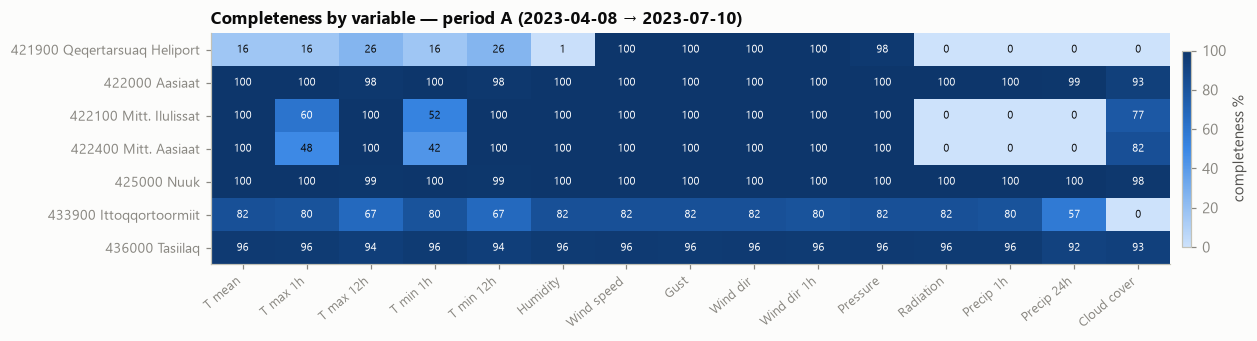

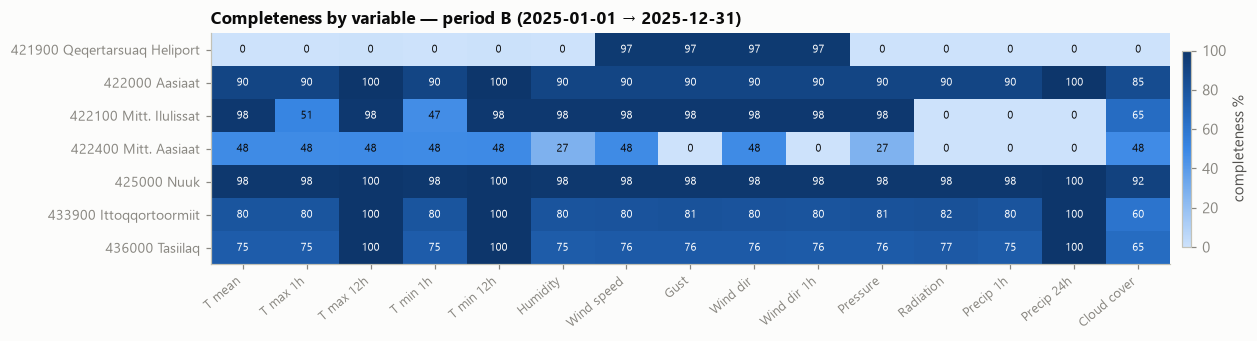

'nd' = station has no rows at all in this period; 0 = variable not reported by that station.


In [6]:
# ---- completeness heatmap: station x variable, one panel per period ----
param_order = list(PARAMS)
param_labels = [PARAMS[v]['short'] for v in param_order]
for p in PERIODS:
    sub = summary[summary['period'] == p]
    if sub.empty:
        print(f'Period {p}: no data to plot')
        continue
    mat = np.full((len(STATIONS), len(param_order)), np.nan)
    labels = []
    for i, sid in enumerate(STATIONS):
        labels.append(f'{sid} {STATIONS[sid]["name"]}')
        if (p, sid) in raw:
            row = sub[sub['station'] == sid].set_index('variable')['completeness']
            mat[i] = [row.get(v, 0) * 100 for v in param_order]
    cmap = CMAP_SEQ.copy()
    cmap.set_bad(NEUTRAL)
    fig, ax = plt.subplots(figsize=(12.5, 3.2))
    im = ax.imshow(np.ma.masked_invalid(mat), cmap=cmap, vmin=0, vmax=100, aspect='auto')
    ax.set_xticks(range(len(param_order)), param_labels, rotation=40, ha='right', fontsize=8.5)
    ax.set_yticks(range(len(labels)), labels, fontsize=9)
    ax.grid(False)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat[i, j]
            ax.text(j, i, 'nd' if np.isnan(val) else f'{val:.0f}',
                    ha='center', va='center', fontsize=7.5,
                    color='#ffffff' if (not np.isnan(val) and val > 55) else INK)
    cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.01)
    cbar.set_label('completeness %', color=INK2)
    ax.set_title(f'Completeness by variable — period {p} '
                 f'({PERIODS[p][0][:10]} → {PERIODS[p][1][:10]})', loc='left')
    plt.tight_layout()
    plt.show()
print("'nd' = station has no rows at all in this period; 0 = variable not reported by that station.")


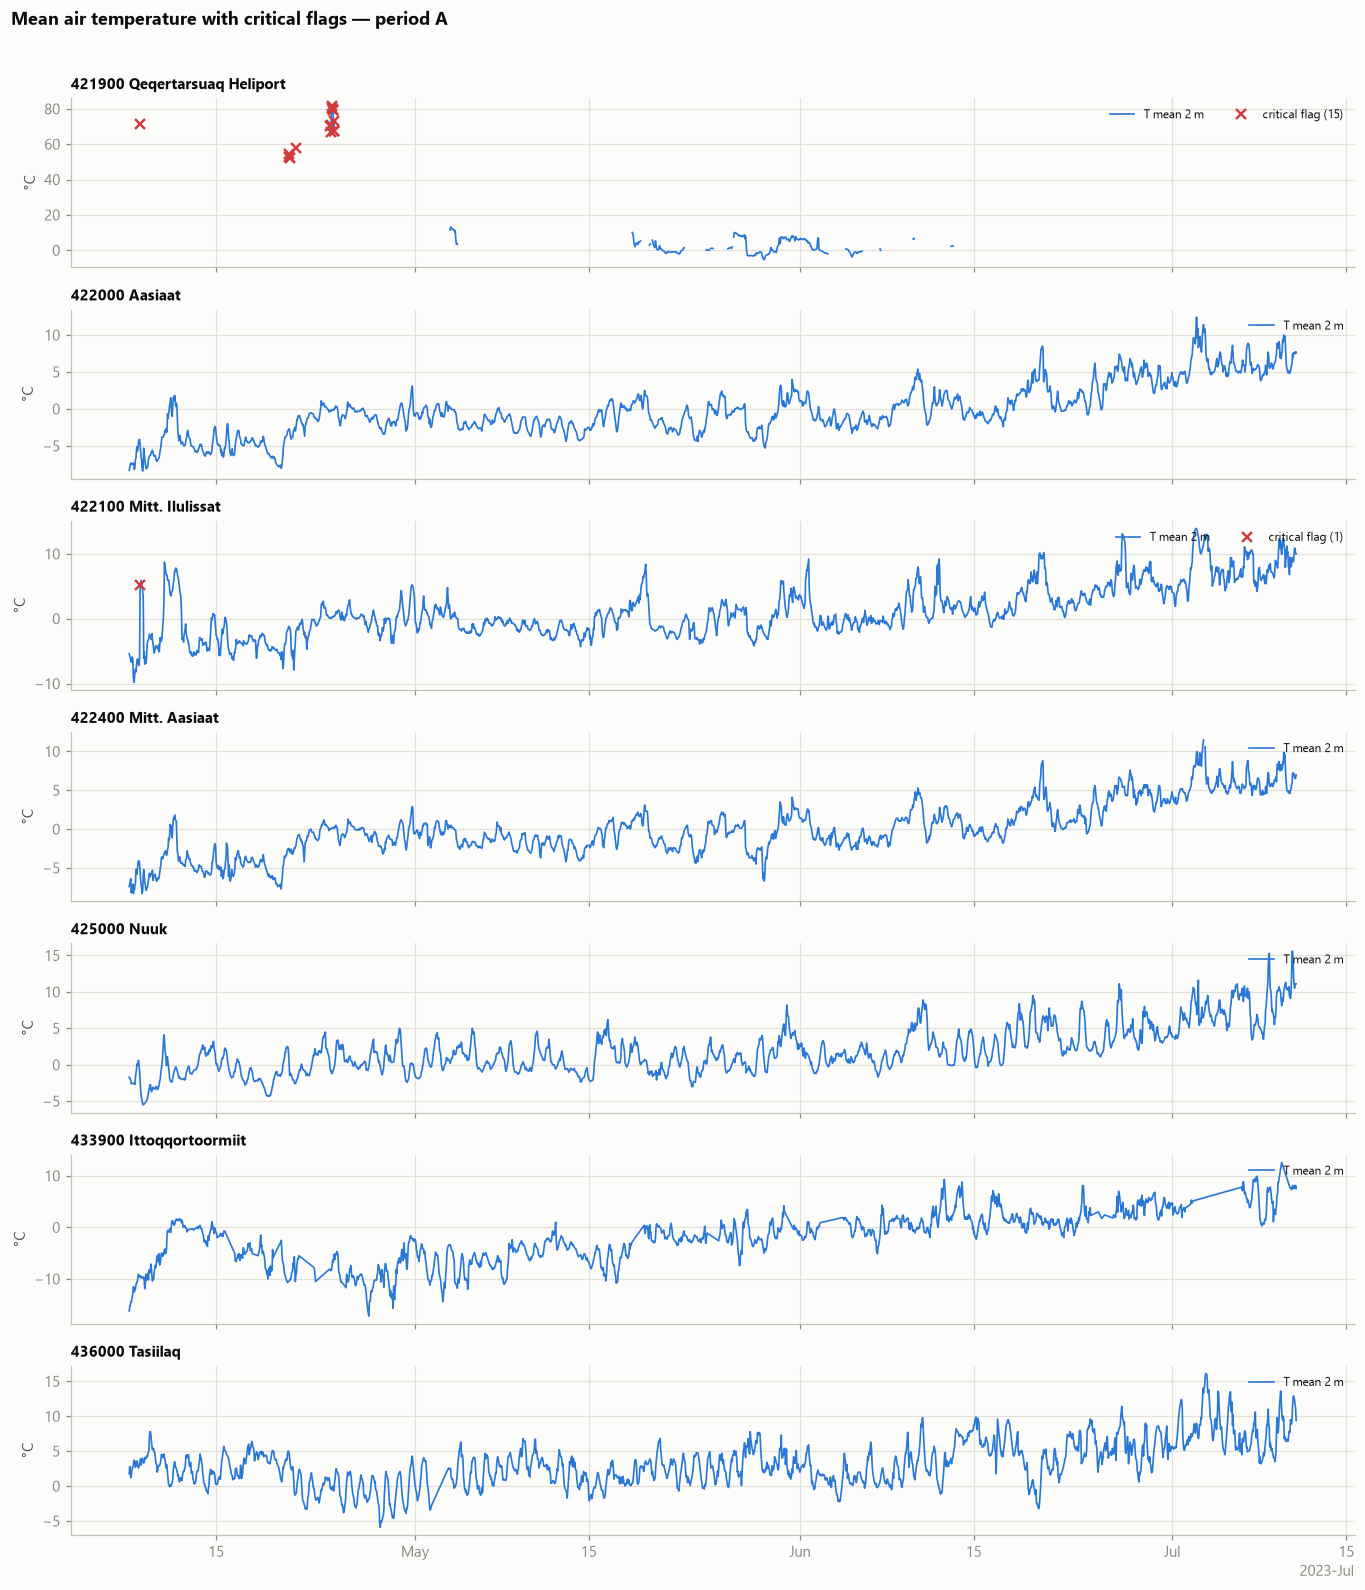

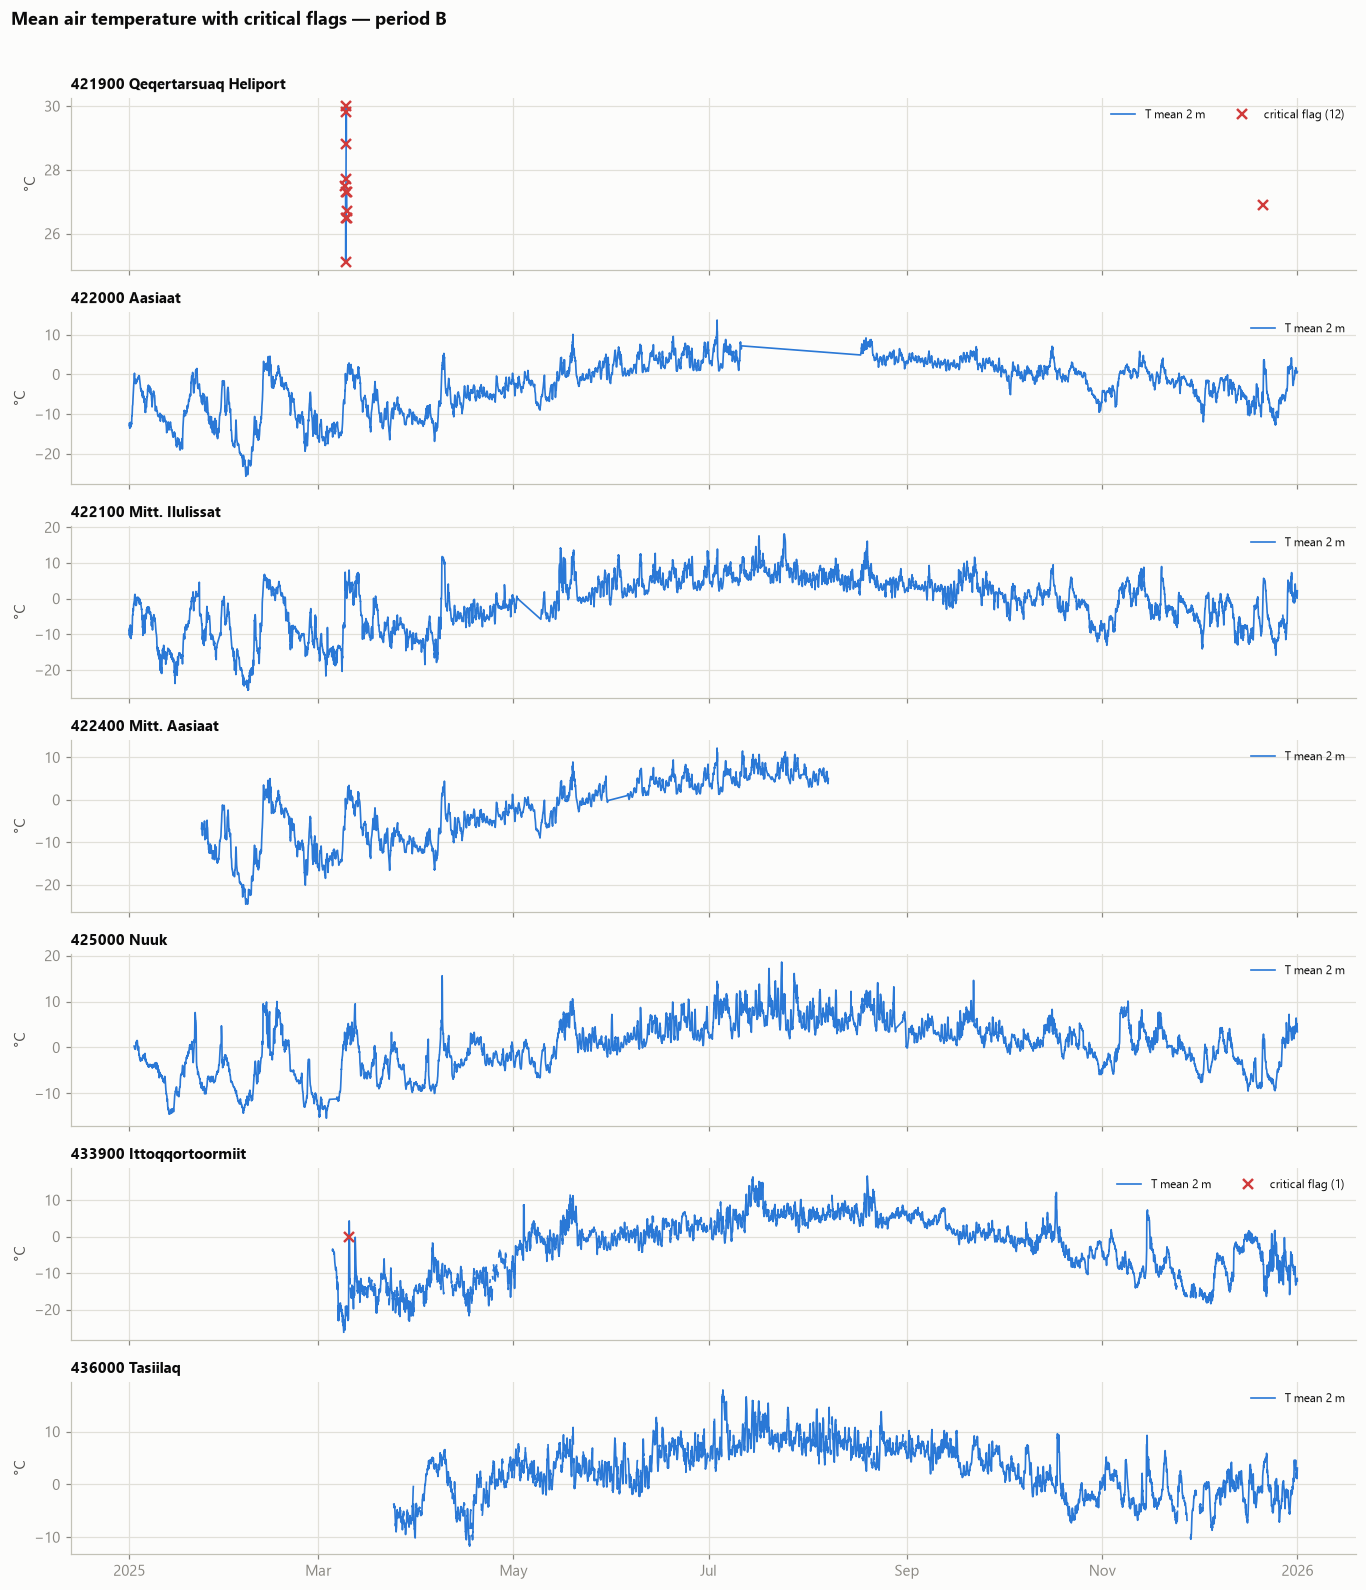

In [7]:
# ---- air temperature with critical flags overlaid, small multiples per period ----
for p in PERIODS:
    have = [sid for sid in STATIONS if (p, sid) in raw and '101' in raw[(p, sid)]]
    if not have:
        print(f'Period {p}: no temperature data to plot')
        continue
    fig, axes = plt.subplots(len(have), 1, figsize=(12.5, 2.1 * len(have)), sharex=True, squeeze=False)
    axes = axes.ravel()
    for ax, sid in zip(axes, have):
        col = raw[(p, sid)]['101']
        ax.plot(col.index, col.values, color=SERIES, lw=1.1, label='T mean 2 m')
        fl = flags[(flags['period'] == p) & (flags['station'] == sid) &
                   (flags['variable'] == '101') & flags['check'].isin(CRITICAL_CHECKS)]
        if len(fl):
            ax.plot(fl['ts'], fl['value'], 'x', color=CRITICAL_C, ms=6, mew=1.6,
                    label=f'critical flag ({len(fl)})')
        ax.set_title(f'{sid} {STATIONS[sid]["name"]}', loc='left', fontsize=10)
        ax.set_ylabel('°C')
        ax.legend(loc='upper right', ncols=2, fontsize=8)
    axes[-1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(axes[-1].xaxis.get_major_locator()))
    fig.suptitle(f'Mean air temperature with critical flags — period {p}', x=0.01, ha='left',
                 fontsize=12, fontweight='bold')
    plt.tight_layout(rect=(0, 0, 1, 0.97))
    plt.show()


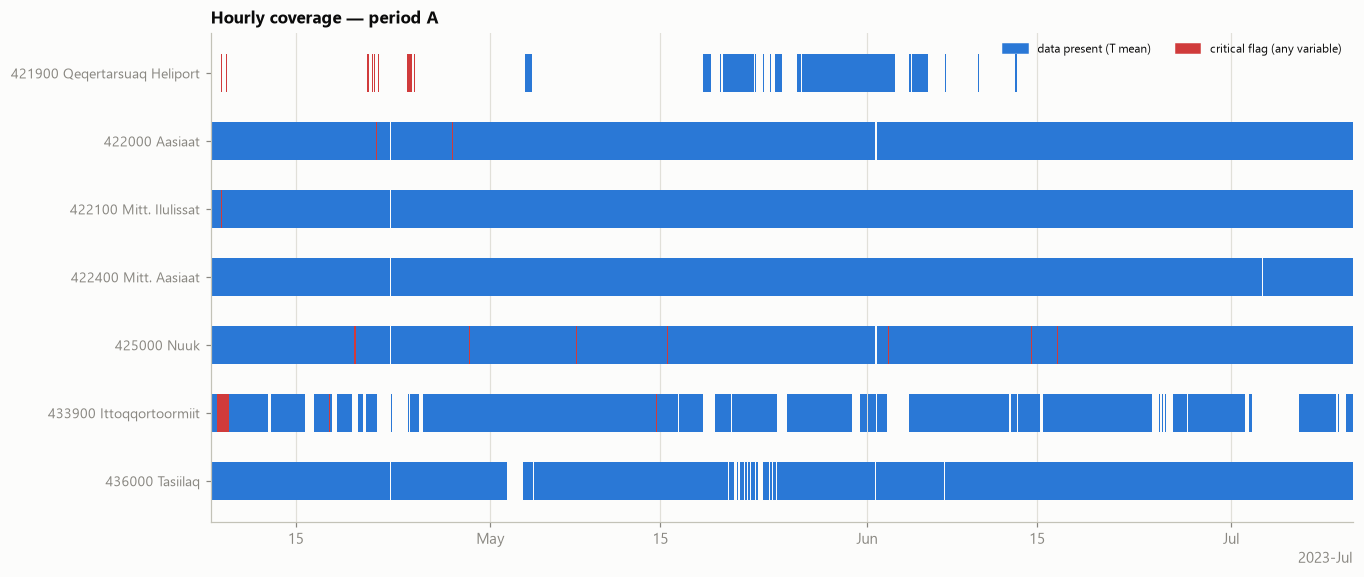

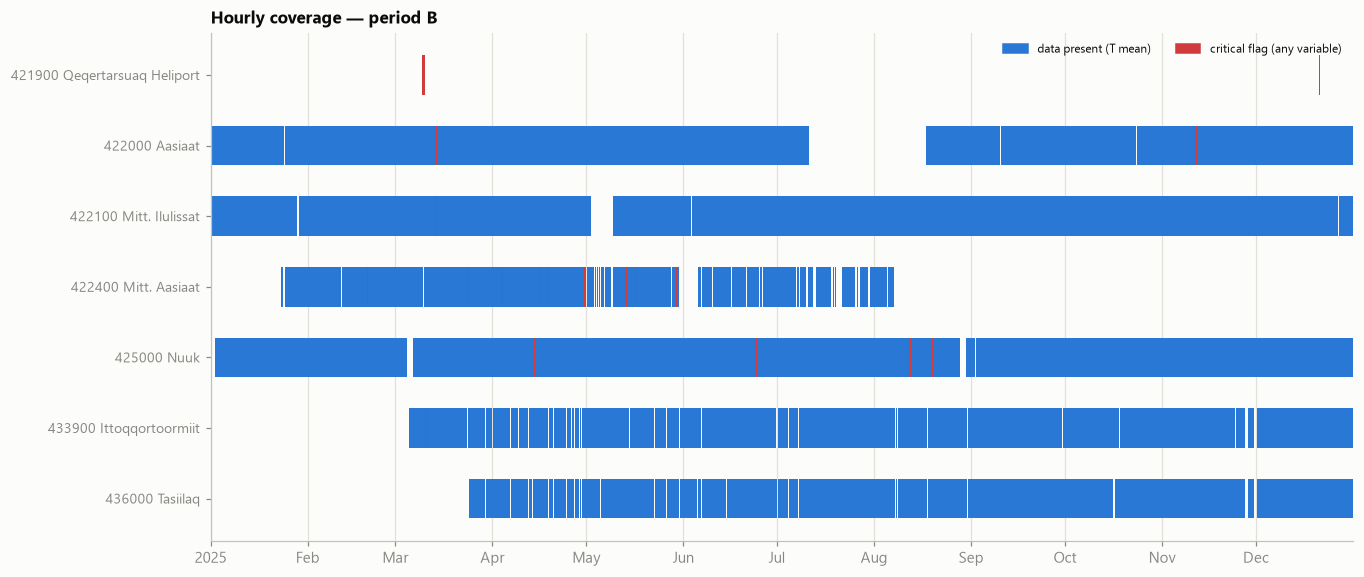

In [8]:
# ---- hourly coverage timeline (based on T mean): blue = present, gap = missing, red = critical flag ----
for p in PERIODS:
    if not any((p, sid) in raw for sid in STATIONS):
        print(f'Period {p}: no data to plot')
        continue
    start, end = pd.Timestamp(PERIODS[p][0]), pd.Timestamp(PERIODS[p][1])
    grid = pd.date_range(start, end, freq='h')
    fig, ax = plt.subplots(figsize=(12.5, 0.55 * len(STATIONS) + 1.5))
    yticks, ylabels = [], []
    for i, sid in enumerate(STATIONS):
        y = len(STATIONS) - 1 - i
        yticks.append(y)
        ylabels.append(f'{sid} {STATIONS[sid]["name"]}')
        if (p, sid) not in raw or '101' not in raw[(p, sid)]:
            continue
        s = raw[(p, sid)]['101']
        s = s[~s.index.duplicated()]
        present = s.notna().reindex(grid, fill_value=False)
        run = (present != present.shift()).cumsum()
        for _, seg in present.groupby(run):
            if seg.iloc[0]:
                x0 = mdates.date2num(seg.index[0])
                x1 = mdates.date2num(seg.index[-1] + pd.Timedelta(hours=1))
                ax.broken_barh([(x0, x1 - x0)], (y - 0.28, 0.56), color=SERIES, lw=0)
        fl = flags[(flags['period'] == p) & (flags['station'] == sid) & flags['check'].isin(CRITICAL_CHECKS)]
        for t in pd.to_datetime(fl['ts'].unique()):
            ax.broken_barh([(mdates.date2num(t), 2 / 24)], (y - 0.28, 0.56), color=CRITICAL_C, lw=0)
    ax.set_yticks(yticks, ylabels, fontsize=9)
    ax.set_ylim(-0.6, len(STATIONS) - 0.4)
    ax.set_xlim(mdates.date2num(start), mdates.date2num(end))
    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    ax.grid(axis='y', visible=False)
    ax.legend(handles=[Patch(color=SERIES, label='data present (T mean)'),
                       Patch(color=CRITICAL_C, label='critical flag (any variable)')],
              loc='upper right', ncols=2, fontsize=8)
    ax.set_title(f'Hourly coverage — period {p}', loc='left')
    plt.tight_layout()
    plt.show()


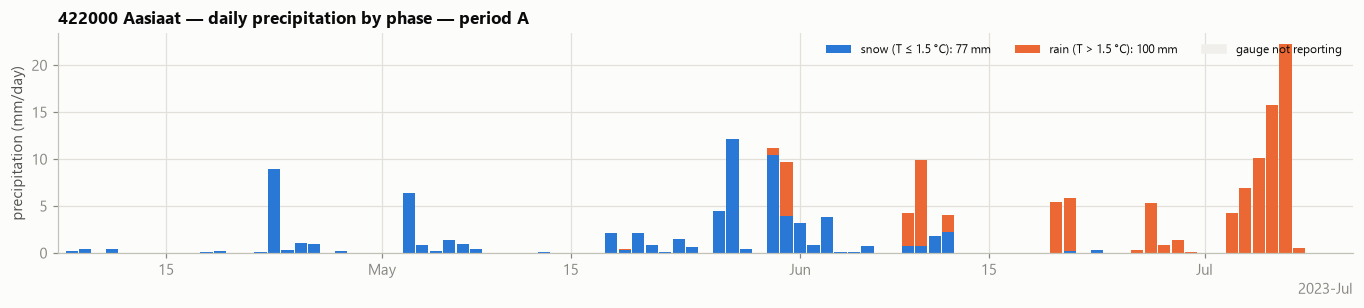

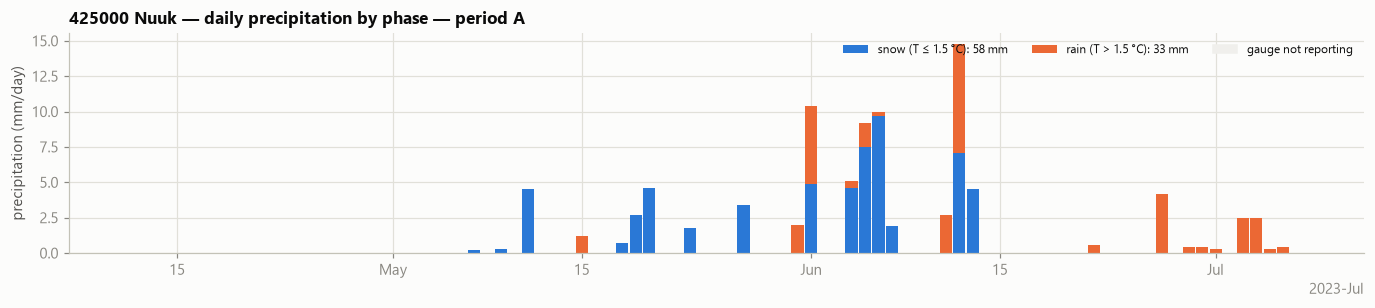

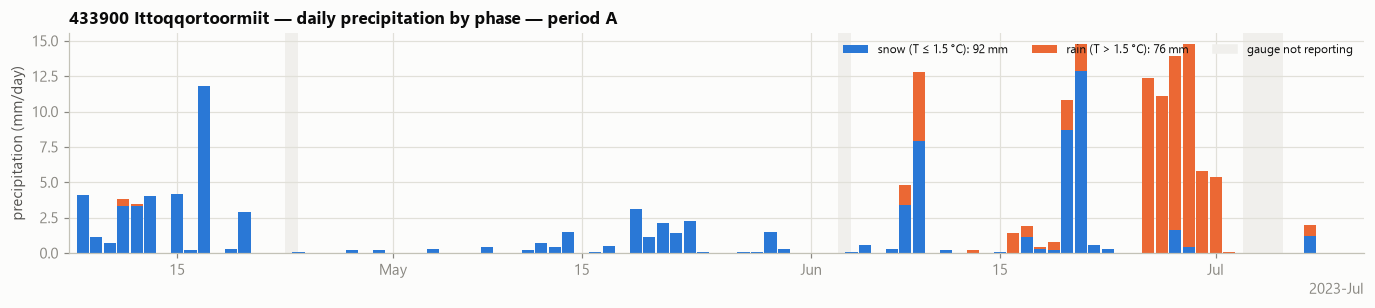

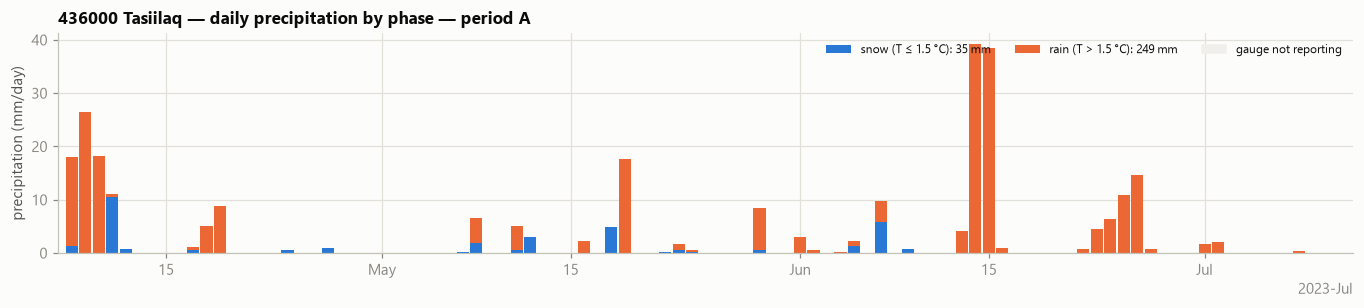

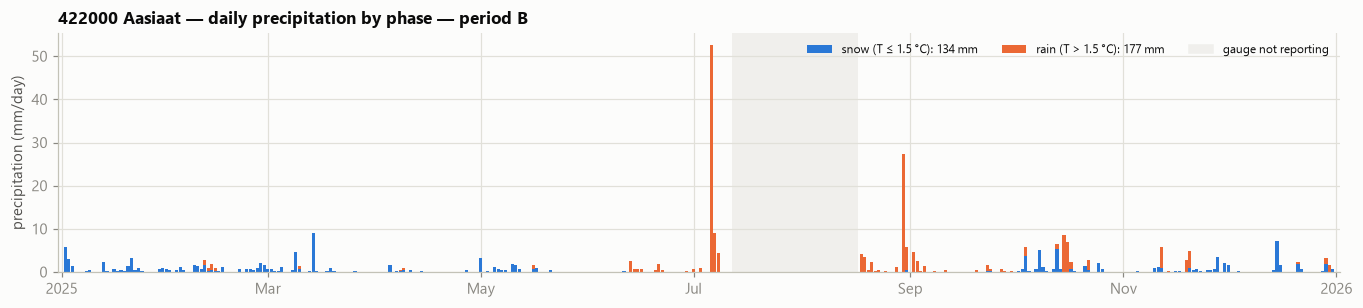

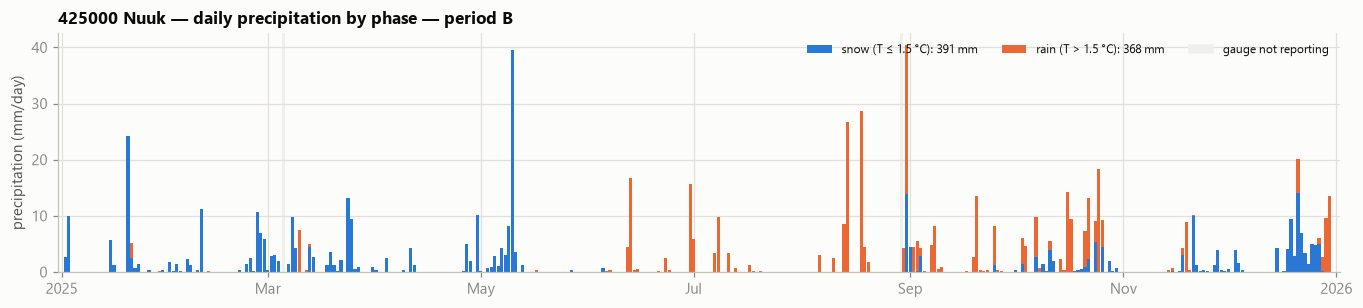

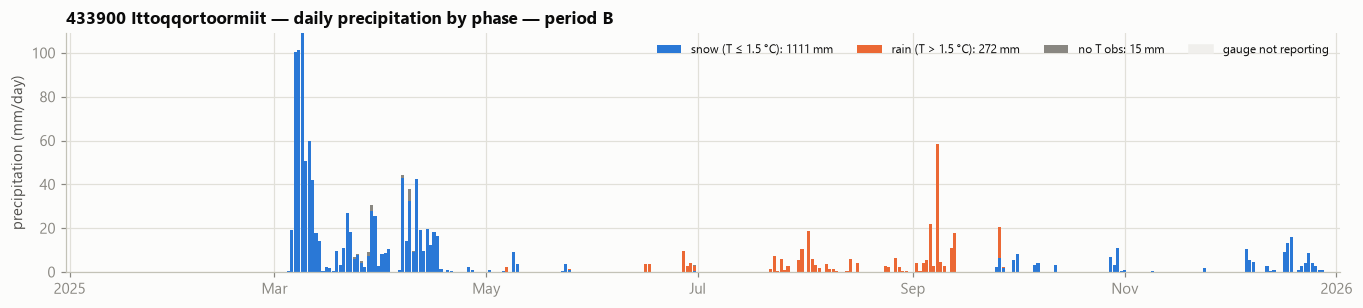

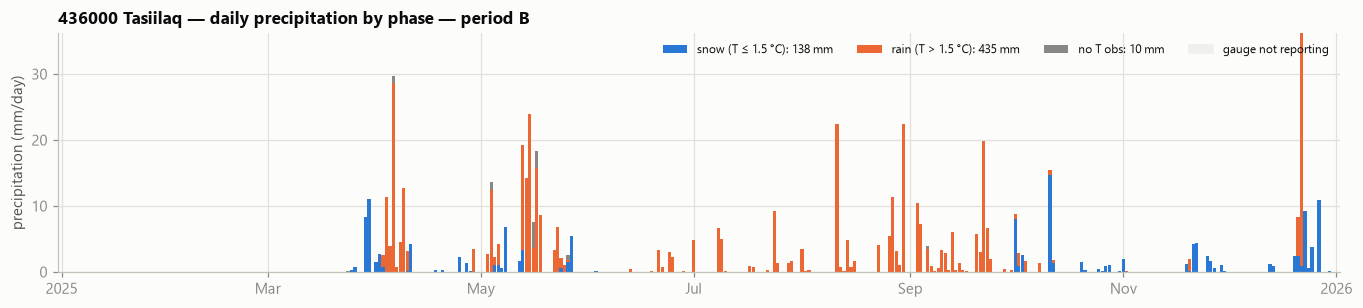

In [9]:
# ---- daily precipitation by phase (snow/rain split by air T) for every station with an
# ---- hourly gauge: Aasiaat plus the three stations added 2026-08 (Nuuk, Ittoqqortoormiit, Tasiilaq).
# Calendar-day UTC sums (for gauge-to-gauge comparisons DMI's 06-06 UTC convention applies instead).
SNOW_T = 1.5   # degC: hourly precip in hours with T <= SNOW_T counted as snow
RAIN_C = '#eb6834'   # categorical slot 2 (orange)
PRECIP_STATIONS = [422000, 425000, 433900, 436000]
for p in PERIODS:
  for sid in PRECIP_STATIONS:
    key = (p, sid)
    if key not in raw or '601' not in raw[key] or raw[key]['601'].notna().sum() == 0:
        print(f'Period {p}: no hourly precipitation at {sid} {STATIONS[sid]["name"]}')
        continue
    df = raw[key]
    pr = df['601'].replace(-0.1, 0.0).clip(lower=0)
    t = df['101']
    daily = pd.DataFrame({
        'snow': pr.where(t <= SNOW_T, 0.0).resample('D').sum(),
        'rain': pr.where(t > SNOW_T, 0.0).resample('D').sum(),
        'unclassified': pr.where(t.isna(), 0.0).resample('D').sum(),
        'n_obs': pr.resample('D').count(),
    })
    fig, ax = plt.subplots(figsize=(12.5, 2.9))
    for run_start, run_end in ((g.index[0], g.index[-1]) for _, g in
                               daily[daily['n_obs'] == 0].groupby((daily['n_obs'] != 0).cumsum()) if len(g)):
        ax.axvspan(run_start, run_end + pd.Timedelta(days=1), color=NEUTRAL, lw=0, zorder=0)
    ax.bar(daily.index, daily['snow'], width=0.9, color=SERIES, lw=0,
           label=f'snow (T ≤ {SNOW_T:g} °C): {daily["snow"].sum():.0f} mm')
    ax.bar(daily.index, daily['rain'], width=0.9, bottom=daily['snow'], color=RAIN_C, lw=0,
           label=f'rain (T > {SNOW_T:g} °C): {daily["rain"].sum():.0f} mm')
    if daily['unclassified'].sum() > 0:
        ax.bar(daily.index, daily['unclassified'], width=0.9,
               bottom=daily['snow'] + daily['rain'], color=MUTED, lw=0,
               label=f'no T obs: {daily["unclassified"].sum():.0f} mm')
    ax.set_ylabel('precipitation (mm/day)')
    ax.set_xlim(pd.Timestamp(PERIODS[p][0]) - pd.Timedelta(days=1),
                pd.Timestamp(PERIODS[p][1]) + pd.Timedelta(days=1))
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    handles, _ = ax.get_legend_handles_labels()
    handles.append(Patch(color=NEUTRAL, label='gauge not reporting'))
    ax.legend(handles=handles, loc='upper right', ncols=4, fontsize=8)
    ax.set_title(f'{sid} {STATIONS[sid]["name"]} — daily precipitation by phase — period {p}', loc='left')
    plt.tight_layout()
    plt.show()


## 5. Verdicts & cleaned exports

Rules (per station × period, evaluated on the **core variables** T mean / humidity / wind speed /
pressure *after masking critically flagged values*):

- **NO DATA** — no observations in the period.
- **FAIL** — any core variable with completeness < 50 %, or critical flags on > 2 % of its values.
- **PASS** — every core variable ≥ 80 % complete, critical flags ≤ 0.5 %, stuck-sensor flags ≤ 5 %.
- **PASS WITH WARNINGS** — everything in between (usable, but read the reasons).

The cleaned files (`results/clean_<station>_<period>.csv`) have critically flagged values masked to
NaN and trace precipitation (−0.1) normalized to 0 — these are the files downstream snowfall
validation should read.

In [10]:
for stale in RESULTS_DIR.glob('clean_4*.csv'):
    stale.unlink()   # remove this notebook's own previous exports (never GEM's clean_GEM_AWS2_*)

verdict_rows = []
for p in PERIODS:
    for sid in STATIONS:
        name = STATIONS[sid]['name']
        key = (p, sid)
        if key not in raw or len(raw[key]) == 0:
            reason = ('fetch failed: ' + fetch_errors[sid]) if sid in fetch_errors else 'no observations in period'
            verdict_rows.append(dict(period=p, station=sid, name=name, verdict='NO DATA',
                                     reasons=reason, **{f'comp_{v}': np.nan for v in CORE_VARS}))
            continue

        df = raw[key]
        cleaned = df.reindex(columns=list(PARAMS)).copy()
        fl = flags[(flags['period'] == p) & (flags['station'] == sid)]
        crit = fl[fl['check'].isin(CRITICAL_CHECKS)]
        for v, grp in crit.groupby('variable'):
            cleaned.loc[cleaned.index.isin(grp['ts']), v] = np.nan
        for v in ('601', '609'):
            cleaned[v] = cleaned[v].replace(-0.1, 0.0)
        cleaned.to_csv(RESULTS_DIR / f'clean_{sid}_{p}.csv')

        comp, flag_frac, pers_frac = {}, {}, {}
        for v in CORE_VARS:
            comp[v] = cleaned[v].notna().sum() / (PARAMS[v]['per_day'] * n_days[p])
            n_obs = max(int(df[v].notna().sum()) if v in df else 0, 1)
            flag_frac[v] = ((crit['variable'] == v).sum()) / n_obs
            pers_frac[v] = ((fl['check'] == 'persistence') & (fl['variable'] == v)).sum() / n_obs

        if min(comp.values()) < THRESHOLDS['completeness_min'] or max(flag_frac.values()) > THRESHOLDS['flagged_max']:
            verdict = 'FAIL'
        elif (min(comp.values()) >= THRESHOLDS['completeness_pass']
              and max(flag_frac.values()) <= THRESHOLDS['flagged_pass']
              and max(pers_frac.values()) <= THRESHOLDS['persistence_frac']):
            verdict = 'PASS'
        else:
            verdict = 'PASS WITH WARNINGS'

        reasons = []
        for v in CORE_VARS:
            vname = PARAMS[v]['short']
            if comp[v] < THRESHOLDS['completeness_pass']:
                reasons.append(f'{vname} completeness {comp[v]:.0%}')
            if flag_frac[v] > THRESHOLDS['flagged_pass']:
                reasons.append(f'{vname} critically flagged {flag_frac[v]:.1%}')
            if pers_frac[v] > THRESHOLDS['persistence_frac']:
                reasons.append(f'{vname} stuck-sensor flags {pers_frac[v]:.1%}')
        n_cross = int((fl['check'] == 'cross_station').sum())
        if n_cross:
            reasons.append(f'{n_cross} cross-station disagreements with the Aasiaat pair')
        verdict_rows.append(dict(period=p, station=sid, name=name, verdict=verdict,
                                 reasons='; '.join(reasons) or 'all checks passed',
                                 **{f'comp_{v}': round(comp[v], 3) for v in CORE_VARS}))

verdicts = pd.DataFrame(verdict_rows)
verdicts.to_csv(RESULTS_DIR / 'station_verdicts.csv', index=False)
print(f'Wrote {RESULTS_DIR / "station_verdicts.csv"} and '
      f'{len(list(RESULTS_DIR.glob("clean_*.csv")))} cleaned station files.')
display(verdicts)

print('Stations usable per period (PASS or PASS WITH WARNINGS):')
for p in PERIODS:
    ok = verdicts[(verdicts['period'] == p) & verdicts['verdict'].str.startswith('PASS')]
    print(f"  period {p}: {', '.join(f'{r.station} {r.name}' for r in ok.itertuples()) or 'none'}")


Wrote c:\Users\marti\Desktop\SnoWhere\results\station_verdicts.csv and 15 cleaned station files.


,period,station,name,verdict,reasons,comp_101,comp_201,comp_301,comp_401
0,A,421900,Qeqertarsuaq Heliport,FAIL,T mean completeness 16%; T mean critically fla...,0.157,0.012,0.998,0.975
1,A,422000,Aasiaat,PASS,all checks passed,0.998,0.997,0.998,0.998
2,A,422100,Mitt. Ilulissat,PASS,all checks passed,0.999,0.999,0.999,0.999
3,A,422400,Mitt. Aasiaat,PASS,all checks passed,0.998,0.998,0.998,0.996
4,A,425000,Nuuk,PASS,all checks passed,0.998,0.997,0.998,0.998
5,A,433900,Ittoqqortoormiit,PASS,all checks passed,0.824,0.824,0.824,0.824
6,A,436000,Tasiilaq,PASS,all checks passed,0.965,0.964,0.965,0.965
7,B,421900,Qeqertarsuaq Heliport,FAIL,T mean completeness 0%; T mean critically flag...,0.000,0.000,0.969,0.000
8,B,422000,Aasiaat,PASS,all checks passed,0.897,0.897,0.897,0.897
9,B,422100,Mitt. Ilulissat,PASS,all checks passed,0.977,0.977,0.977,0.977


Stations usable per period (PASS or PASS WITH WARNINGS):
  period A: 422000 Aasiaat, 422100 Mitt. Ilulissat, 422400 Mitt. Aasiaat, 425000 Nuuk, 433900 Ittoqqortoormiit, 436000 Tasiilaq
  period B: 422000 Aasiaat, 422100 Mitt. Ilulissat, 425000 Nuuk, 433900 Ittoqqortoormiit, 436000 Tasiilaq


In [11]:
# ---- positive controls: ground truths established earlier must be reproduced ----
a = flags[(flags['period'] == 'A') & (flags['station'] == 421900) &
          (flags['variable'] == '101') & (flags['check'] == 'range')]
assert len(a) == 14, f'expected the 14 known bad temperature rows at 421900 in period A, got {len(a)}'
assert a['ts'].min() >= pd.Timestamp('2023-04-08') and a['ts'].max() <= pd.Timestamp('2023-04-25')

v = verdicts.set_index(['period', 'station'])
# the API archive has 2023 data for 422400 even though the report files were silent 2021-2023
assert v.loc[('A', 422400), 'verdict'] != 'NO DATA', '422400 period A must be evaluated from API data'
assert (RESULTS_DIR / 'station_verdicts.csv').exists()
assert (RESULTS_DIR / 'clean_422000_A.csv').exists()

clean_ex = pd.read_csv(RESULTS_DIR / 'clean_421900_A.csv', index_col='ts')
assert clean_ex['101'].max() <= PARAMS['101']['hi'], 'cleaned export must not contain out-of-range temperatures'
print('All positive-control assertions passed.')


All positive-control assertions passed.


## 6. Snow depth — documented negative result for DMI

Snow depth is not in the DMI product for Greenland at all: none of the 126 Greenland stations in
the DMI registry declare a snow parameter (`snow_depth_man` is Denmark-only). This cell re-checks
the observations endpoint for our stations and periods so the negative result is reproducible.
For in-situ snow depth near Disko Bay use **GEM ClimateBasis Disko** (Arctic Station,
Qeqertarsuaq — data.g-e-m.dk) or **PROMICE/GC-Net** surface height (GEUS, ice sheet).

In [12]:
session = requests.Session()
rows = []
for p, (start, end) in PERIODS.items():
    t0 = pd.Timestamp(start).strftime('%Y-%m-%dT%H:%M:%SZ')
    t1 = pd.Timestamp(end).strftime('%Y-%m-%dT%H:%M:%SZ')
    for sid, meta in STATIONS.items():
        try:
            s = fetch_parameter(session, meta['wmo'], 'snow_depth_man', t0, t1)
        except Exception as e:
            print(f'{sid} period {p}: snow fetch failed - {type(e).__name__}: {e}')
            continue
        if len(s):
            rows.append(dict(period=p, station=sid, name=meta['name'], n_obs=len(s),
                             first=s.index.min(), last=s.index.max(),
                             min_cm=s.min(), max_cm=s.max(), n_trace=int((s == -1).sum())))
if rows:
    display(pd.DataFrame(rows))
else:
    print('Confirmed: no snow_depth_man observations for these stations in either period.')


Confirmed: no snow_depth_man observations for these stations in either period.


## 7. How to use this downstream

1. **Filter stations** with `results/station_verdicts.csv`: keep `PASS` / `PASS WITH WARNINGS`
   for the period you're validating; drop `FAIL` / `NO DATA`.
2. **Read the cleaned data** from `results/clean_<station>_<period>.csv` (UTC index, report
   parameter codes as columns) — critical flags are already masked and trace precipitation
   normalized, so no re-cleaning is needed.
3. **Snowfall-rate specifics**: hourly precipitation (`601`) exists only at **422000 Aasiaat**;
   combine it with air temperature (`101`, e.g. snow when T ≲ +1.5 °C) to derive an in-situ
   snowfall-rate proxy. The other stations still contribute temperature, wind (drifting-snow
   caveats), humidity and pressure for coherence checks against model/EO fields.
4. In-situ snow depth comes from other products (GEM ClimateBasis Disko at Qeqertarsuaq,
   PROMICE/GC-Net on the ice sheet) — see section 6.
5. Thresholds are deliberately conservative and live in `THRESHOLDS` (section 1) — loosen or
   tighten and re-run to see how the verdicts respond.